# Predicting the Activity of the Combinatorial Library 
The random forest [QSAR](02_random_forest.ipynb) model is used to classify a library of novel candidates obtained in a combinatorial fashion ([combinatorial library notebook](02_generative/01_combinat_lib.ipynb)). A synthesis recommendation based on the `Predicted Activity`, `Applicability Domain`, `Molecular Weight`, and `Chemical Diversity` was made.  

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [2]:
### Standard imports
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit as rd
import seaborn as sns
from tqdm import tqdm
import sklearn as sk

In [3]:
### Specific imports
from rdkit.Chem import Descriptors
import astartes as at

## Jupyter Settings

In [4]:
### Random seed - using the same seed for robustness
SEED = 0
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
rd.RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# rd.RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames. 
- `utils/sk_qsar.py` contains individual functions for bulding QSAR models with scikit-learn. 
- The class [`MorganSimilarity`](`../utils/similarity_sali.py`) is used as container for the training data. 

In [5]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))
from pd_mol import render_mol
from similarity_sali import MorganSimilarity
import sk_qsar

# Models
Unpack all required pre-trained models are stored in the [`RfClfAppDom`](../utils/sk_qsar.py) object. 

In [6]:
### Load the morgan object
with open("../data/03_rf_ad_class.pkl", "rb") as file:
    rf_app_dom = pickle.load(file)

### Unpacking the random forest model
rf_model = rf_app_dom.rf_model

### Unpacking the PCA model
pca_model = rf_app_dom.pca_model

### AD threshold
threshold = rf_app_dom.threshold

# Data

**Training Data**

In [7]:
### Load the transformed training data
X_train = rf_app_dom.X_train

X_train.shape

(2157, 32)

**Combinatorial Library**

,Mol
ID,
acid-163_amine-5_yne-2553_yne-2553,
acid-62_amine-10_yne-3050_yne-3050,
acid-163_amine-15_yne-3399_yne-3399,

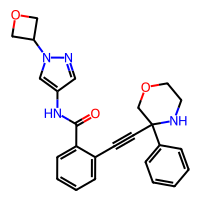
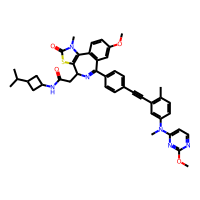
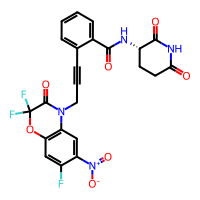

In [8]:
### Load the new data
df = pd.read_pickle("../data/02_comb_amide_yne_library.pkl")
render_mol(df.sample(3))

**Morgan Fingerprints**


The features of the training data were generated using method `utils.similarity_sali.MorganSimilarity.get_morgan_fingerprint()`with `radius = 3` and  `nBits = 2048`. Because Morgan fingerprints are deterministic a new instance can be used. 

In [9]:
### Instantiate the class
morgan = MorganSimilarity(df, radius=3, nBits=2048, useChirality=True)

### Get the Morgan fingerprints
morgan.get_morgan_fingerprint()

### Format the fingerprints as NumPy array
morgan.format_fp("np_array")

morgan.fp.shape

(85704, 2048)

**Dimensionality Reduction**

The number of festures is reduce from **2048** to **32** by the same `PCA` model used to transform the training data.  

In [10]:
X_new = pca_model.transform(morgan.fp)

X_new.shape

(85704, 32)

**Visualization**

Visualization the chemical space for **85k** new compounds was not feasible by `sklearn.manifold.TSNE`. Instead the **2** first PCsare used for plotting. 

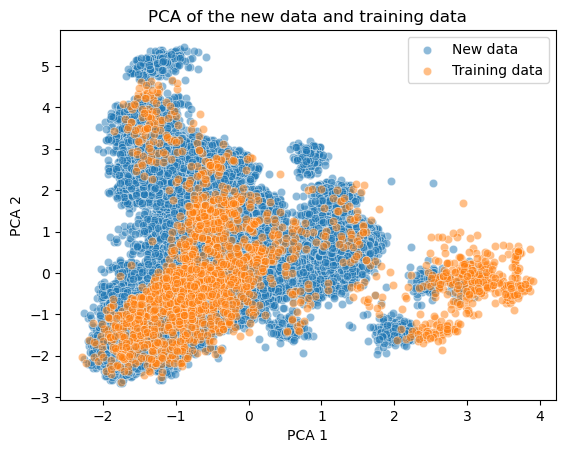

In [11]:
### Plot the PCs of the new data
sns.scatterplot(
    x=X_new[:, 0],
    y=X_new[:, 1],
    alpha=0.5,
    label="New data",
)

### Plot the PCs of the training data
sns.scatterplot(
    x=X_train[:, 0],
    y=X_train[:, 1],
    alpha=0.5,
    label="Training data",
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.title("PCA of the new data and training data")
plt.show()

**Analysis**

The plot demonstrates that the majority of new compounds are in proximity to the training data. That some compounds are expected to be outside the models applicability domain can also be determined by visual inspection.  


,Mol
ID,
acid-1_amine-1,
acid-1_amine-2,
acid-1_amine-3,

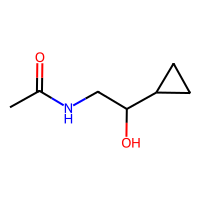
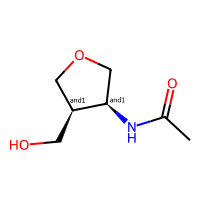
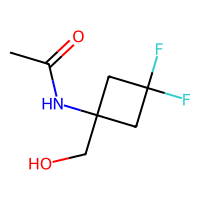

In [12]:
### New compounds expected to be outside AD
render_mol(df.head(3))

# Predictions

**Activity Labels**

In [13]:
### Predict the labels
df["pred_label"] = rf_model.predict(X_new).astype(bool)

### Predict the probabilities
df["pred_proba"] = rf_model.predict_proba(X_new)[:, 1].astype(float)

,Mol,pred_label,pred_proba
ID,,,
acid-105_amine-23_yne-753_yne-753,,True,0.66
acid-64_amine-28_yne-2101_yne-2101,,True,0.82
acid-141_amine-43_yne-753_yne-753,,False,0.00

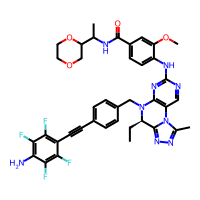
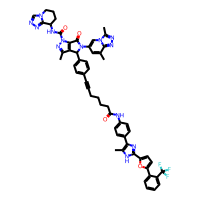
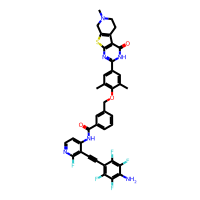

In [14]:
render_mol(df.sample(3))

**Applicability Domain**

Due to the large batch size of the new compounds (**85 k**) the applicability domain has to be predicted in chunks to limit memory usage during the calculations. 

In [15]:
AD_df = pd.DataFrame()
chunk_size = 1000

### Calculate the applicability domain in chunks
for i in range(0, len(df), chunk_size):
    ### Subset data
    X_new_chunk = X_new[i : i + chunk_size]
    df_chunk = df.iloc[i : i + chunk_size]

    ### Instantiate the class
    rf_app_dom = sk_qsar.RfClfAppDom(rf_model, df_chunk, threshold=threshold)

    ### Fit the model
    rf_app_dom.fit(X_train, X_new_chunk)

    ### Predict the applicability domain
    AD_chunk_df = rf_app_dom.predict(print_stats=False)

    ### Append to the main DataFrame
    AD_df = pd.concat([AD_df, AD_chunk_df], axis=0)

In [16]:
### Add AD labels to the main DataFrame
df[['AD_status', 'AD_value']] = AD_df[['AD_status', 'AD_value']]

**Moleculare Weight**

The training data have a moleculare weight of **250** to **600** `g/mol`. The same filter will be applied to the combinatorial library. 

In [17]:
### Calculating molecular weights
df['MW'] = df['Mol'].apply(Descriptors.MolWt).astype(float)

### MW cut-offs used in pre-processing
lower_cut_off = 200  
upper_cut_off = 650  

# subsetting df
df['MW_status'] = (df['MW'] >= lower_cut_off) & (df['MW'] <= upper_cut_off)

# Analysis
**Default Filters**

Using default filters:
- `AD > 0.6`
- `250 < MW < 600`
- `pred_proba > 0.5`
 
 **16k** new compounds pass all criteria (see below). Notably, the random forest-specific applicability domain theshold `AD = 0.6` does not exclude any of the novel compounds.  

/home/oskar/anaconda3/envs/brd4/lib/python3.11/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


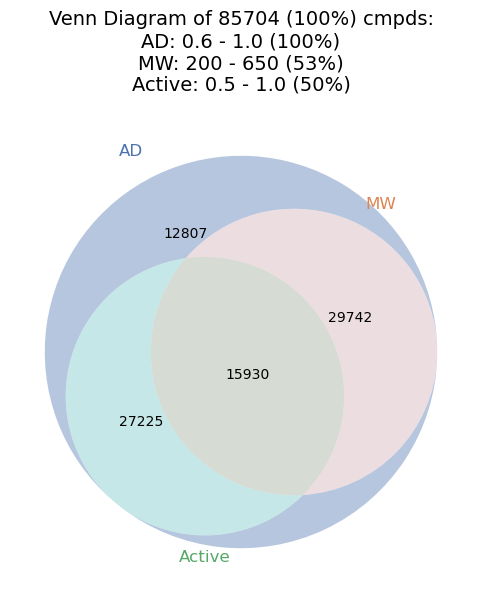

In [18]:
### Dictionary with defaul thresholds
threshold_dict = {
    "AD_value": [0.6, 1.0],  # Must match a column in `df`
    "MW": [200, 650],  # Must match a column in `df`
    "pred_proba": [0.5, 1.0],  # Must match a column in `df`
}

### Labels for plotting
labels = ["AD", "MW", "Active"]

### Venn diagram
full_mask = sk_qsar.plot_venn3(df, threshold_dict, labels)

# Synthesis Recommendation
The **16 k** compds can be used in further virtual screening and filtering steps, but it can also be further reduced with the information given. This is achieved by applying more restrictive thresholds. The function `[utils.sk_qsar.plot_venn3](../utils/sk_qsar.py) can be used to modify thresholds and visualize the effect. *Note:* Compounds not passing any filter are not represented in the plot. This filters are restricted manually in order to reach a subset of **~500** cmpds.  

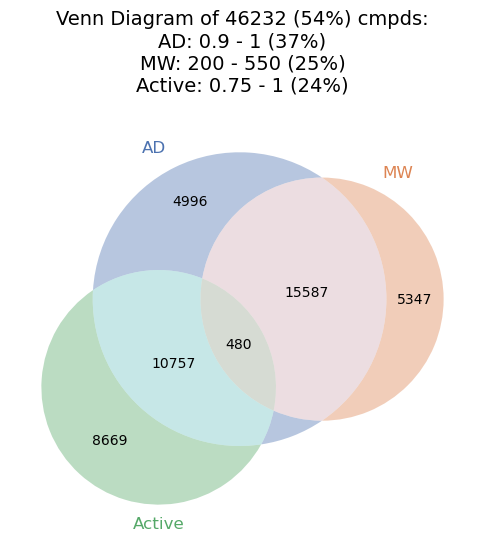

In [19]:
### Dictionary with more restrictive thresholds
threshold_dict = {
    "AD_value": [0.9, 1],  # Must match a column in `df`
    "MW": [200, 550],  # Must match a column in `df`
    "pred_proba": [0.75, 1],  # Must match a column in `df`
}

### Venn diagram
mask_500 = sk_qsar.plot_venn3(df, threshold_dict, labels)


In [20]:
### Create a column for synthesis recommendation
df['synth'] = None
df['synth'] = df['synth'].astype(object)
df.loc[mask_500, 'synth'] = "top_500"

**Kennard-Stone** 

Rather then reducing the number of compounds by restricting the test set further. A diversity sample is taken by applying the `Kennard-Stone` algorithm. 

In [21]:
### Train-test-split unsing Kennard-Stone and Morgan fingerprints
X_synth, X_drop, synth_idx, drop_idx = at.train_test_split(
    X_new[mask_500],
    df.loc[mask_500].index.values,
    test_size=0.95,     # 95% of the data will be dropped
    train_size=0.05,    # 5% of the data will be suggested for synthesis
    sampler="kennard_stone",
)

In [ ]:
### Add labels for diversity set
df.loc[synth_idx, 'synth'] = "top_25"

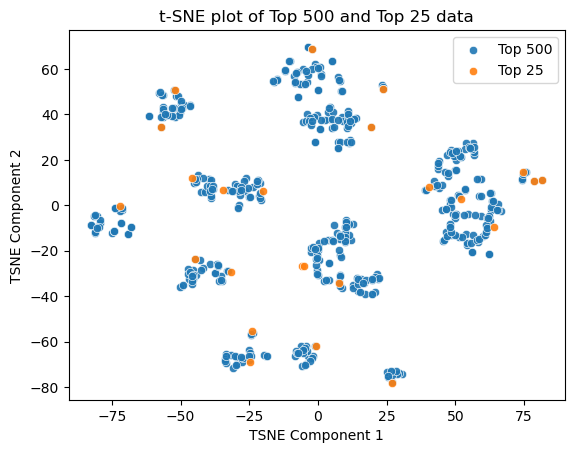

In [35]:
### TSNE plot of data split
sk_qsar.plot_tsne(X_drop, X_synth, label_0="Top 500", label_1="Top 25", learning_rate=200, perplexity=5)

**Visual inspection**

The `top_25` compounds are displayed below. *Note:* Synthetic accessibility and physicochemical properties were not considered in this selection.  

,Mol,pred_label,pred_proba,AD_status,AD_value,MW,MW_status,synth
ID,,,,,,,,
acid-3_amine-9,,True,0.89,True,0.94,495.01,True,top_25
acid-50_amine-39,,True,0.86,True,0.90,536.68,True,top_25
acid-64_amine-21,,True,0.90,True,0.94,548.05,True,top_25
acid-41_amine-9,,True,0.89,True,0.94,548.55,True,top_25
acid-15_amine-35,,True,0.95,True,0.98,476.94,True,top_25
acid-53_amine-23,,True,0.84,True,0.90,490.56,True,top_25
acid-20_amine-48,,True,0.85,True,0.92,391.50,True,top_25
acid-39_amine-38,,True,0.83,True,0.90,490.95,True,top_25
acid-66_amine-31,,True,0.83,True,0.92,533.98,True,top_25

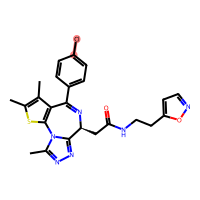
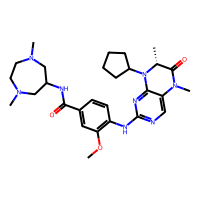
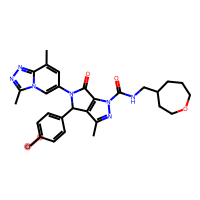
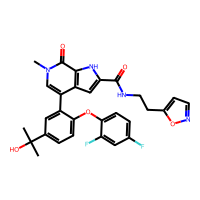
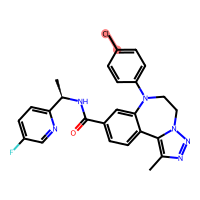
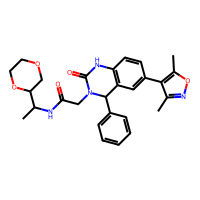
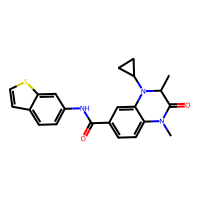
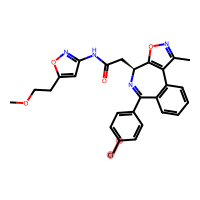
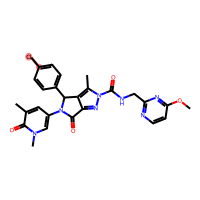
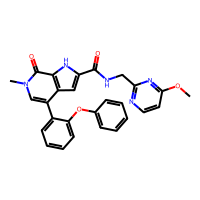
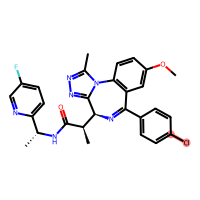
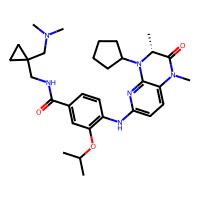
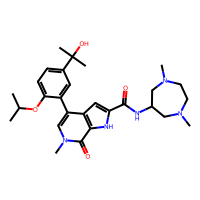
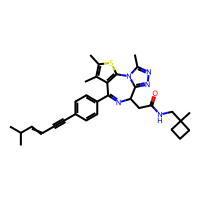
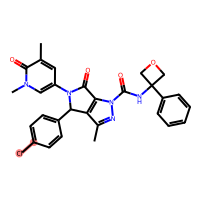
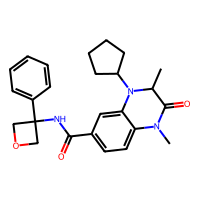
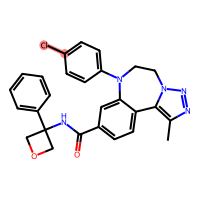
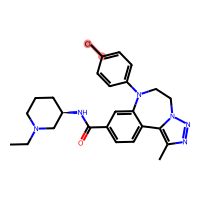
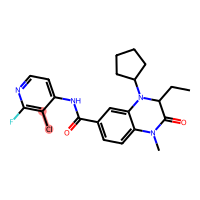
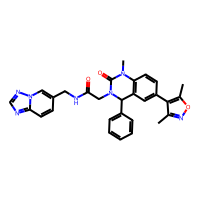
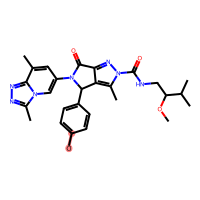
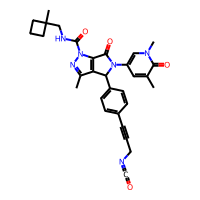
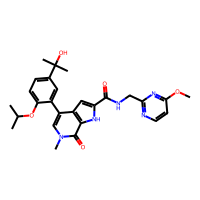
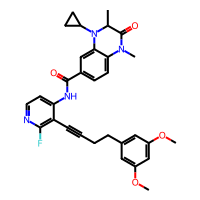

In [23]:
render_mol(df.loc[synth_idx])

# Export 

In [37]:
df.to_pickle("../data/03_pred_comb_library_Rf.pkl")